# **Comparison of Antarctic freshwater projections across spatial aggregations**




*Whole ice sheet, ocean sectors, and Zwally drainage basins under SSP126 and SSP585*

For an interactive version of this page please visit the Google Colab: [Open in Google Colab](https://colab.research.google.com/drive/1l4MRAoOhMVw9JGY27geBR7OSNPsOhgsC#scrollTo=CQqjXzCQIX_I)

*(To open link in new tab press Ctrl + click)*

Alternatevly this notebook can be opened with Binder by following the link: [Comparison of Antarctic freshwater projections across spatial aggregations](https://mybinder.org/v2/gh/s4oceanice/literacy.s4oceanice/main?urlpath=%2Fdoc%2Ftree%2Fnotebooks_binder%2Foceanice_SSP126vsSSP585_freshwater_comparison.ipynb)

**Scientific background**

The same Antarctic freshwater projection can be summarized at different spatial resolutions. Whole-ice-sheet data provide an integrated total, ocean sectors group fluxes according to their receiving Southern Ocean region, and Zwally basins represent drainage-based subdivisions of the ice sheet.

Comparing the total dataset with sums reconstructed from finer spatial units is a useful consistency check and can reveal differences related to spatial aggregation, missing units, or dataset conventions.


**Notebook objctives**

This notebook enables users to:

- retrieve projections at three spatial aggregation levels;
- compare SSP126 and SSP585;
- sum sector and basin values by time;
- compare reconstructed totals with the whole-Antarctic dataset;
- assess consistency among spatial representations.


**Data source**

The data, available on the OCEAN ICE ERDDAP server (<https://er1.s4oceanice.eu/erddap>), cover the period 1990–2300 and are provided at three different spatial resolutions:

- **Total AIS**: the whole ice sheet as a single domain
- **Ocean Sectors**: 5 sectors of the Southern Ocean
- **Zwally Basins**: 27 glaciological drainage basins

For each resolution, two scenario are provided:
- **Low-emission scenario** (SSP126 datasets)
- **High-emission scenario** (SSP585 dataset)

For each resolution, four variables are available:
- net mass balance (*Net_Mass_Balance*),
- surface meltwater runoff (*Surface_Meltwater_Runoff_Fluxes*),
- sub-shelf melt of ice shelves (*Sub_Shelf_Melt_Fluxes*),
- and calving flux (*Calving_Fluxes*).



**Note:** each variable is queried at the 0.05 and 0.95 percentiles, which represent the lower and upper bounds of the projection's uncertainty range, not a central estimate. Keep this in mind when interpreting the plots below.

The goal of this notebook is to check consistency across resolutions: does summing the 5 ocean sectors, or the 27 Zwally basins, reproduce the total AIS value?

**How to use this notebook**

1. Run the code cells sequentially from top to bottom.
2. Wait for the remote dataset to be downloaded and processed.
3. Use the available menus, sliders, or map controls to select the variables and periods of interest.
4. Read the interpretation guidance before drawing scientific conclusions from the visualizations.

The notebook retrieves data from remote services. An active internet connection is therefore required.


 **1. Dataset configuration and SSP126 retrieval**

The first code section defines the six ERDDAP queries, creates a reusable loading function, and downloads the three SSP126 datasets.


In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# URLs for AIS (Total)
url_ais_126 = "https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D"
url_ais_585 = "https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_AIS.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(0.0):1:(0.0)%5D"

# URLs for Ocean Sectors
url_sectors_126 = "https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_OceanSectors.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D"
url_sectors_585 = "https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_OceanSectors.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(5.0)%5D"

# URLs for Zwally Basins
url_zwally_126 = "https://er1.s4oceanice.eu/erddap/griddap/SSP126_FWF_1990_2300_ZwallyBasins.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D"
url_zwally_585 = "https://er1.s4oceanice.eu/erddap/griddap/SSP585_FWF_1990_2300_ZwallyBasins.csv?Net_Mass_Balance%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Surface_Meltwater_Runoff_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Sub_Shelf_Melt_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D,Calving_Fluxes%5B(0.05):1:(0.95)%5D%5B(1990.0):1:(2300.0)%5D%5B(1.0):1:(27.0)%5D"

def load_erddap_csv(url):
    df = pd.read_csv(url, skiprows=[1])
    return df

print("Data loading...")
ais_126 = load_erddap_csv(url_ais_126)
sect_126 = load_erddap_csv(url_sectors_126)
zwally_126 = load_erddap_csv(url_zwally_126)

print("Loaded data. AIS Example:")
display(ais_126.head())

Data loading...
Loaded data. AIS Example:


,quantile,time2,basin,Net_Mass_Balance,Surface_Meltwater_Runoff_Fluxes,Sub_Shelf_Melt_Fluxes,Calving_Fluxes
0,0.05,1990.0,0,-377.78043,10.740931,661.0331,848.25934
1,0.05,1991.0,0,-323.43260,10.375707,662.9677,977.39070
2,0.05,1992.0,0,-284.03833,9.997697,658.8721,1083.82820
3,0.05,1993.0,0,-249.58664,9.526503,656.1268,1099.65890
4,0.05,1994.0,0,-248.05067,9.260891,650.4208,970.86810


**2. SSP585 retrieval**

The next cell uses the same loading function to retrieve the whole-Antarctic, ocean-sector, and Zwally-basin datasets for SSP585.

In [ ]:
# @title
ais_585 = load_erddap_csv(url_ais_585)
sect_585 = load_erddap_csv(url_sectors_585)
zwally_585 = load_erddap_csv(url_zwally_585)

**3. Cross-resolution comparison**

The final section sums the selected variable by time for each spatial representation and plots the whole-Antarctic values against totals reconstructed from sectors and basins.


**Results visualization**

The comparison plots show whether the whole-Antarctic series is reproduced by summing the corresponding sector or basin records.

Close agreement suggests internally consistent aggregation. Persistent offsets or diverging trajectories may indicate differences in filtering, quantile handling, spatial definitions, duplicated records, missing values, or source conventions.


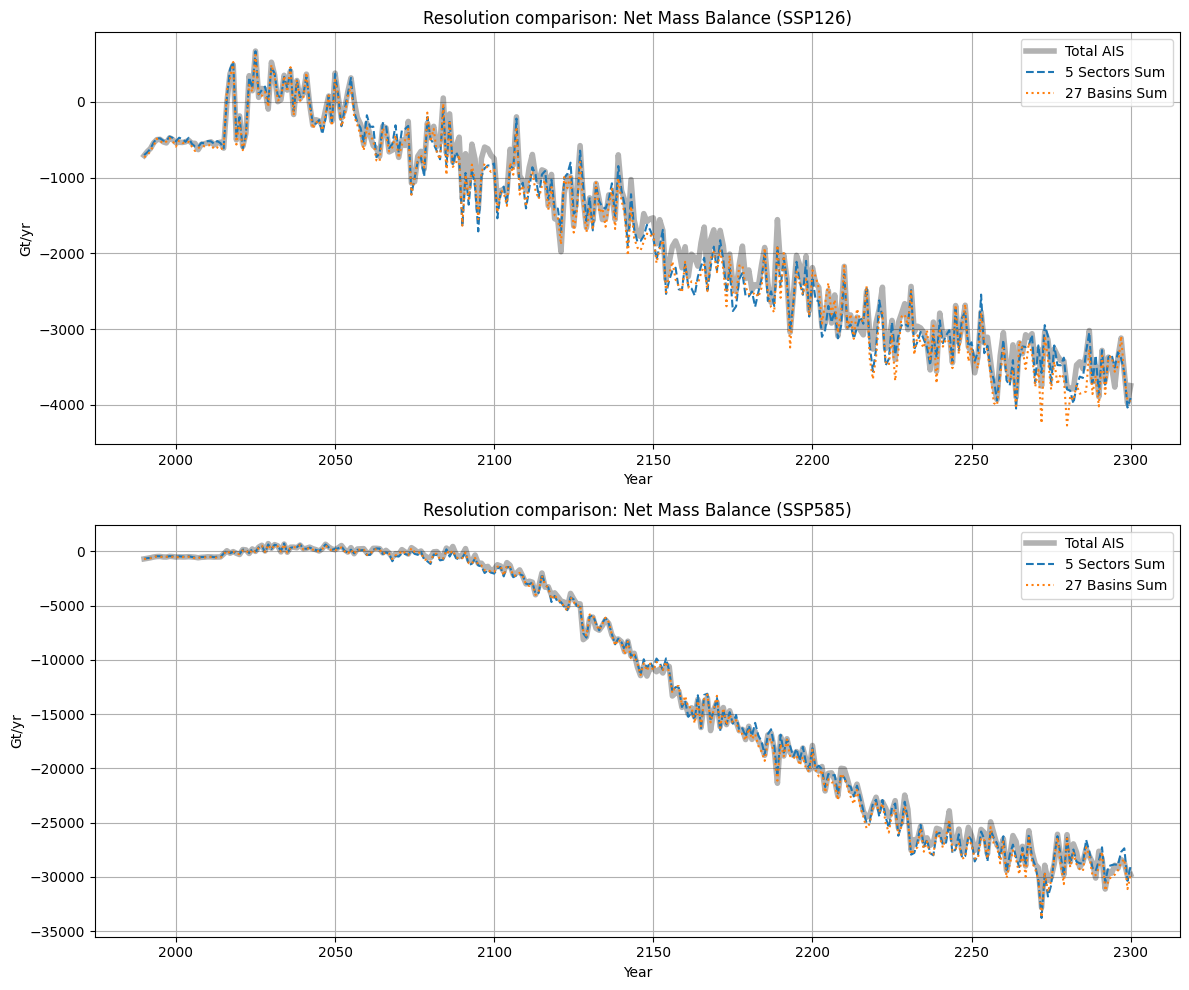

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

def compare_resolutions(df_ais, df_sect, df_zwally, var_name='Net_Mass_Balance'):
    ais_total = df_ais.groupby('time2')[var_name].sum()
    sect_total = df_sect.groupby('time2')[var_name].sum()
    zwally_total = df_zwally.groupby('time2')[var_name].sum()

    comparison = pd.DataFrame({
        'AIS_Total': ais_total,
        'Sectors_Summed': sect_total,
        'Zwally_Summed': zwally_total
    })
    return comparison

comp_126 = compare_resolutions(ais_126, sect_126, zwally_126)
comp_585 = compare_resolutions(ais_585, sect_585, zwally_585)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot SSP126
ax1.plot(comp_126.index, comp_126['AIS_Total'], label='Total AIS', linewidth=4, alpha=0.3, color='black')
ax1.plot(comp_126.index, comp_126['Sectors_Summed'], label='5 Sectors Sum', linestyle='--')
ax1.plot(comp_126.index, comp_126['Zwally_Summed'], label='27 Basins Sum', linestyle=':')
ax1.set_title('Resolution comparison: Net Mass Balance (SSP126)')
ax1.set_ylabel('Gt/yr')
ax1.set_xlabel('Year')
ax1.legend()
ax1.grid(True)

# Plot SSP585
ax2.plot(comp_585.index, comp_585['AIS_Total'], label='Total AIS', linewidth=4, alpha=0.3, color='black')
ax2.plot(comp_585.index, comp_585['Sectors_Summed'], label='5 Sectors Sum', linestyle='--')
ax2.plot(comp_585.index, comp_585['Zwally_Summed'], label='27 Basins Sum', linestyle=':')
ax2.set_title('Resolution comparison: Net Mass Balance (SSP585)')
ax2.set_ylabel('Gt/yr')
ax2.set_xlabel('Year')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Interpretation guidance**

Spatial totals should only be compared after confirming that the same variable, quantile, year, unit, and sign convention are used. Summing observations across quantiles does not reconstruct a probabilistic uncertainty interval unless the quantile fields are handled consistently.

The notebook should therefore be treated as a diagnostic consistency check rather than proof that all spatial products are mathematically interchangeable.


**Additional resources and acknowledgement**

Main resources used across the notebook series include:

- [pandas](https://pandas.pydata.org/docs/)
- [matplotlib](https://matplotlib.org/stable/index.html)
- [ipywidgets](https://ipywidgets.readthedocs.io/)

This work has received funding from the European Union Horizon Europe project Ocean-Cryosphere Exchanges in ANtarctica: Impacts on Climate and the Earth System (OCEAN ICE) under grant agreement No. 101060452 (<https://doi.org/10.3030/101060452>). UK partners are funded by UK Research and Innovation (UKRI) under the UK government's Horizon Europe funding guarantee.

<center>
  <div style="display: flex; justify-content: center; align-items: flex-start; gap: 80px;">
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/TO-USE-RGB-for-digital-materials-V.png" height="140" style="margin-top: 50px;"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2025/02/UKRI-logo-1.png" height="100"/>
    <img src="https://ocean-ice.eu/wp-content/uploads/2023/06/logo-polar-cluster-2.png" height="100"/>
  </div>
</center>